# Stuttering Detection: Advanced Neural Network Analysis
---

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from src.data import DataManager
from src.extractors import WavLMExtractor
from src.models import ShallowNeuralNetwork, DeepNeuralNetwork
from sklearn.decomposition import PCA

## Step 2: Configuration & Operational Flags

In [ ]:
# Constants
SAMPLE_LIMIT = None
STRICT_LABELS = True # Set to True to filter out ambiguous samples (Score 1 & 2)
RANDOM_SEED = 42
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
AUDIO_DIR = "Stuttering Events in Podcasts Dataset/clips/stuttering-clips/clips"
FEATURE_DIR = "data/features"
fluent_dir = "non_stutter"
disfluent_dir = os.path.join(FEATURE_DIR, "disfluent")

# Operational Flags
SKIP_EXTRACTION = True
FORCE_EXTRACT = False
CLEAN_START = False
NUM_CLIPS_TO_EXTRACT = 1000

## Step 3: (Optional) Data Extraction Process

In [ ]:
if not SKIP_EXTRACTION or CLEAN_START or FORCE_EXTRACT:
    import shutil
    if CLEAN_START and os.path.exists(FEATURE_DIR):
        shutil.rmtree(FEATURE_DIR)
        print("[System] Feature database wiped for clean start.")
    
    extractor = WavLMExtractor("microsoft/wavlm-base")
    label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
    
    extractor.extract_from_dir(
        AUDIO_DIR, 
        output_dir=FEATURE_DIR, 
        label_dict=None, 
        limit=NUM_CLIPS_TO_EXTRACT, 
        random_sample=True
    )
else:
    print("[System] Skipping extraction. Using existing data on disk.")

[System] Skipping extraction. Using existing data on disk.


## Step 4: Standardized Data Loading & Splitting

In [ ]:
# Standardized Data Loading
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

X, y = manager.load_from_folders(fluent_dir, disfluent_dir, limit=SAMPLE_LIMIT, label_dict=None)
X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)

# Balance training data (Fixes class mismatch errors)
X_train_bal, y_train_bal = manager.balance_data(X_train, y_train, strategy="oversample")

# Preprocessing (Zero-Leakage)
X_train_final = manager.preprocess(X_train_bal, method="standard", fit=True)
X_val_final = manager.preprocess(X_val, method="standard", fit=False)
X_test_final = manager.preprocess(X_test, method="standard", fit=False)

print(f"Data Ready: {len(X_train_final)} balanced training samples.")


[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
[DataManager] Strict Filtering: Kept 14452 high-agreement samples (Discarded 11361 ambiguous samples).
Data Ready: 10896 balanced training samples.


In [ ]:
# --- Baseline: Shallow Neural Network ---
print("--- Training Shallow NN Baseline ---")
shallow_nn = ShallowNeuralNetwork("Shallow_NN_Baseline", input_size=X_train_final.shape[1])
shallow_nn.train(X_train_final, y_train_bal, epochs=20, lr=0.001)

print("\n--- Evaluation: Shallow NN ---")
shallow_nn.evaluate(X_test_final, y_test)

# --- Baseline: Deep Neural Network ---
print("--- Training Deep NN Baseline ---")
deep_nn = DeepNeuralNetwork("Deep_NN_Baseline", input_size=X_train_final.shape[1])
deep_nn.train(X_train_final, y_train_bal, epochs=30, lr=0.001)

print("\n--- Evaluation: Deep NN ---")
deep_nn.evaluate(X_test_final, y_test)


--- Training Shallow NN Baseline ---
[Model: Shallow_NN_Baseline] Initialized.
[Shallow_NN_Baseline] Training PyTorch Network (Layers: [100]) for 20 epochs...

--- Evaluation: Shallow NN ---

--- Evaluation: Shallow_NN_Baseline ---
Accuracy: 0.8026
Precision: 0.7901
Recall: 0.7790
F1: 0.7845

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      961             207            
True: Stutter(1)     221             779            
--- Training Deep NN Baseline ---
[Model: Deep_NN_Baseline] Initialized.
[Deep_NN_Baseline] Training PyTorch Network (Layers: (100, 50)) for 30 epochs...

--- Evaluation: Deep NN ---

--- Evaluation: Deep_NN_Baseline ---
Accuracy: 0.8067
Precision: 0.8055
Recall: 0.7660
F1: 0.7852

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      983             185            
True: Stutter(1)     234             766            


{'accuracy': 0.8067343173431735,
 'precision': 0.8054679284963197,
 'recall': 0.766,
 'f1': 0.7852383393131728,
 'confusion_matrix': array([[983, 185],
        [234, 766]])}

## Step 5: Optimized MLP Architecture
Uses BatchNorm, Dropout, and ReLU to prevent vanishing gradients and overfitting.

In [ ]:
class AdvancedStutterNet(nn.Module):
    def __init__(self, config):
        super(AdvancedStutterNet, self).__init__()
        layers = []
        input_dim = config['num_features']
        
        # Pro Dynamic Architecture Construction
        for i, hidden_dim in enumerate(config['hidden_layers']):
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            # Use the first dropout rate for the first layer, second for others
            drop_idx = min(i, len(config['dropout_rates']) - 1)
            layers.append(nn.Dropout(config['dropout_rates'][drop_idx]))
            input_dim = hidden_dim
            
        layers.append(nn.Linear(input_dim, 1)) # Final binary output
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)


## Step 6: Training with History Diagnostics

In [ ]:
# --- FUNCTIONAL HYPERPARAMETER CONTROL CENTER ---
config = {
    "num_features": X_train_final.shape[1],
    "hidden_layers": [256, 128, 64],
    "dropout_rates": [0.3, 0.2],
    "learning_rate": 0.001,
    "epochs": 150,
    "patience": 15  # Early stopping patience
}

def train_stutternet(model, X_train, y_train, X_val, y_val, config):
    X_t, y_t = torch.FloatTensor(X_train), torch.FloatTensor(y_train).view(-1, 1)
    X_v, y_v = torch.FloatTensor(X_val), torch.FloatTensor(y_val).view(-1, 1)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    # Early stopping setup
    patience = config.get('patience', 15)
    best_val_loss = float('inf')
    best_weights = None
    epochs_no_improve = 0
    
    print(f"--- Starting Optimization (up to {config['epochs']} epochs, patience={patience}) ---")
    for epoch in range(config['epochs']):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            v_out = model(X_v)
            v_loss = criterion(v_out, y_v)
            v_acc = ((torch.sigmoid(v_out) > 0.5).float() == y_v).float().mean()
            
        history['train_loss'].append(loss.item())
        history['val_loss'].append(v_loss.item())
        history['val_acc'].append(v_acc.item())
        
        # Early stopping check
        if v_loss.item() < best_val_loss:
            best_val_loss = v_loss.item()
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch+1:03d} | Loss: {loss.item():.4f} | Val Acc: {v_acc.item():.4f}")
        
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} (best val loss: {best_val_loss:.4f})")
            break
    
    # Restore best weights
    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"Restored best weights (val loss: {best_val_loss:.4f})")
    
    return history

advanced_model = AdvancedStutterNet(config)
history = train_stutternet(advanced_model, X_train_final, y_train_bal, X_val_final, y_val, config)


--- Starting Optimization (up to 150 epochs, patience=15) ---
Epoch 025 | Loss: 0.3166 | Val Acc: 0.8238
Epoch 050 | Loss: 0.1498 | Val Acc: 0.8275

Early stopping at epoch 60 (best val loss: 0.3810)
Restored best weights (val loss: 0.3810)


In [ ]:
import os
os.makedirs("reports", exist_ok=True)
# --- DYNAMIC MASTER GRID STUDY (Width vs. Depth) ---
study_grid = {
    'architectures': [[1024, 512], [512, 256], [1024], [512]],
    'learning_rates': [0.005, 0.001]
}

best_acc = 0
best_config = {}
study_results = [] # NEW: To collect data for the CSV

print("| Trial | Depth | Width | LR     | Val Acc |")
print("|-------|-------|-------|--------|---------|")

trial = 1
for arch in study_grid['architectures']:
    for lr in study_grid['learning_rates']:
        config['hidden_layers'] = arch
        config['learning_rate'] = lr
        m = AdvancedStutterNet(config)
        h = train_stutternet(m, X_train_final, y_train_bal, X_val_final, y_val, config)
        
        acc = h['val_acc'][-1]
        depth = len(arch)
        print(f"| {trial:02d}    | {depth}     | {arch[0]} | {lr:.4f} | {acc:.4f}  |")
        
        # NEW: Store result for report
        study_results.append({
            'trial': trial, 'depth': depth, 'width': arch[0], 'lr': lr, 'val_accuracy': acc
        })
        
        if acc > best_acc:
            best_acc = acc
            best_config = config.copy()
        trial += 1

# NEW: Export results to CSV for the leaderboard
pd.DataFrame(study_results).to_csv("reports/nn_hypertuning_benchmarks.csv", index=False)
print(f"\n[System] Benchmarking data saved to reports/nn_hypertuning_benchmarks.csv")

config = best_config
print(f"\n[System] Optimization Complete. Best Depth: {len(config['hidden_layers'])} with Width: {config['hidden_layers'][0]}")


| Trial | Depth | Width | LR     | Val Acc |
|-------|-------|-------|--------|---------|
--- Starting Optimization (up to 150 epochs, patience=15) ---
Epoch 025 | Loss: 0.4169 | Val Acc: 0.8012
Epoch 050 | Loss: 0.3329 | Val Acc: 0.8160
Epoch 075 | Loss: 0.1762 | Val Acc: 0.8293

Early stopping at epoch 80 (best val loss: 0.4063)
Restored best weights (val loss: 0.4063)
| 01    | 2     | 1024 | 0.0050 | 0.8233  |
--- Starting Optimization (up to 150 epochs, patience=15) ---
Epoch 025 | Loss: 0.1894 | Val Acc: 0.8238

Early stopping at epoch 41 (best val loss: 0.3907)
Restored best weights (val loss: 0.3907)
| 02    | 2     | 1024 | 0.0010 | 0.8293  |
--- Starting Optimization (up to 150 epochs, patience=15) ---
Epoch 025 | Loss: 0.3851 | Val Acc: 0.8077
Epoch 050 | Loss: 0.2379 | Val Acc: 0.8183

Early stopping at epoch 63 (best val loss: 0.4021)
Restored best weights (val loss: 0.4021)
| 03    | 2     | 512 | 0.0050 | 0.8252  |
--- Starting Optimization (up to 150 epochs, patience=15

In [ ]:
# --- STEP 6.5: FINAL TRAINING WITH BEST HYPERPARAMETERS ---
# We take the 'best_config' discovered in the grid study and train a fresh model
print("[System] Re-training final model with optimized parameters...")
print(f"Target Configuration: Depth {len(config['hidden_layers'])}, Width {config['hidden_layers'][0]}, LR {config['learning_rate']}")

# 1. Initialize fresh model with best config
advanced_model = AdvancedStutterNet(config)

# 2. Train for the full 150 epochs to capture maximum learning
history = train_stutternet(
    advanced_model, 
    X_train_final, 
    y_train_bal, 
    X_val_final, 
    y_val, 
    config
)

print("\n[System] Final Optimized Training Complete.")


[System] Re-training final model with optimized parameters...
Target Configuration: Depth 2, Width 1024, LR 0.001
--- Starting Optimization (up to 150 epochs, patience=15) ---
Epoch 025 | Loss: 0.1655 | Val Acc: 0.8196

Early stopping at epoch 33 (best val loss: 0.3935)
Restored best weights (val loss: 0.3935)

[System] Final Optimized Training Complete.


## Step 7: Performance Diagnostics

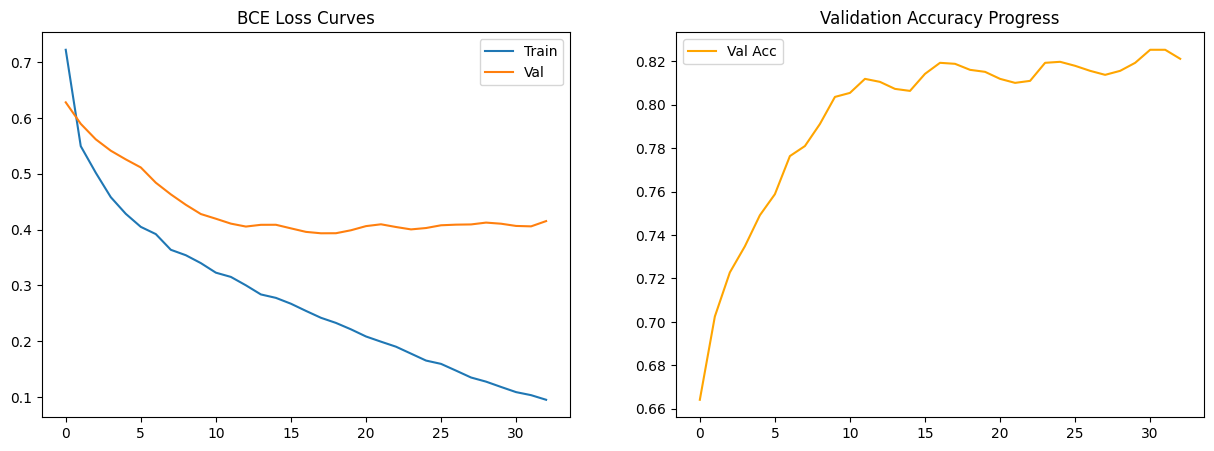


[HARVEST] NN Final Accuracy: 0.8146
[HARVEST] NN Final F1: 0.8077


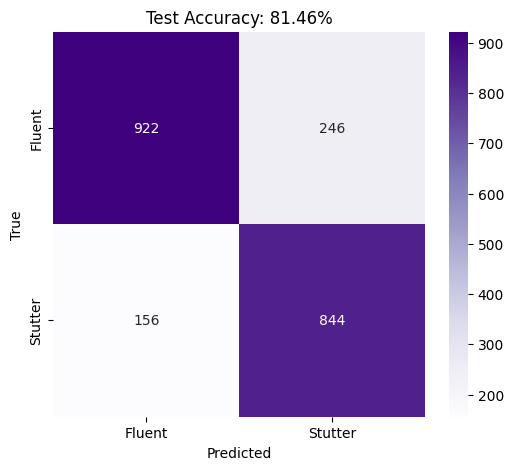

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_title('BCE Loss Curves')
ax1.legend()

ax2.plot(history['val_acc'], color='orange', label='Val Acc')
ax2.set_title('Validation Accuracy Progress')
ax2.legend()
plt.show()

advanced_model.eval()
with torch.no_grad():
    y_pred = (torch.sigmoid(advanced_model(torch.FloatTensor(X_test_final))) > 0.5).numpy().astype(int).flatten()
# HARVEST FOR LEADERBOARD
nn_final_accuracy = accuracy_score(y_test, y_pred)
nn_final_f1 = f1_score(y_test, y_pred) # Calculate F1
print(f"\n[HARVEST] NN Final Accuracy: {nn_final_accuracy:.4f}")
print(f"[HARVEST] NN Final F1: {nn_final_f1:.4f}")
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', xticklabels=['Fluent', 'Stutter'], yticklabels=['Fluent', 'Stutter'])
plt.title(f'Test Accuracy: {nn_final_accuracy*100:.2f}%') # Percentage display
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## Step 8: Model Persistence

In [ ]:
import os
os.makedirs("models", exist_ok=True)
torch.save(advanced_model.state_dict(), "models/stutternet_best.pth")
print("[System] Model exported successfully to models/stutternet_best.pth")


[System] Model exported successfully to models/stutternet_best.pth


--- Starting Optimization (up to 150 epochs, patience=15) ---
Epoch 025 | Loss: 0.6585 | Val Acc: 0.6084
Epoch 050 | Loss: 0.6551 | Val Acc: 0.6056

Early stopping at epoch 52 (best val loss: 0.6538)
Restored best weights (val loss: 0.6538)


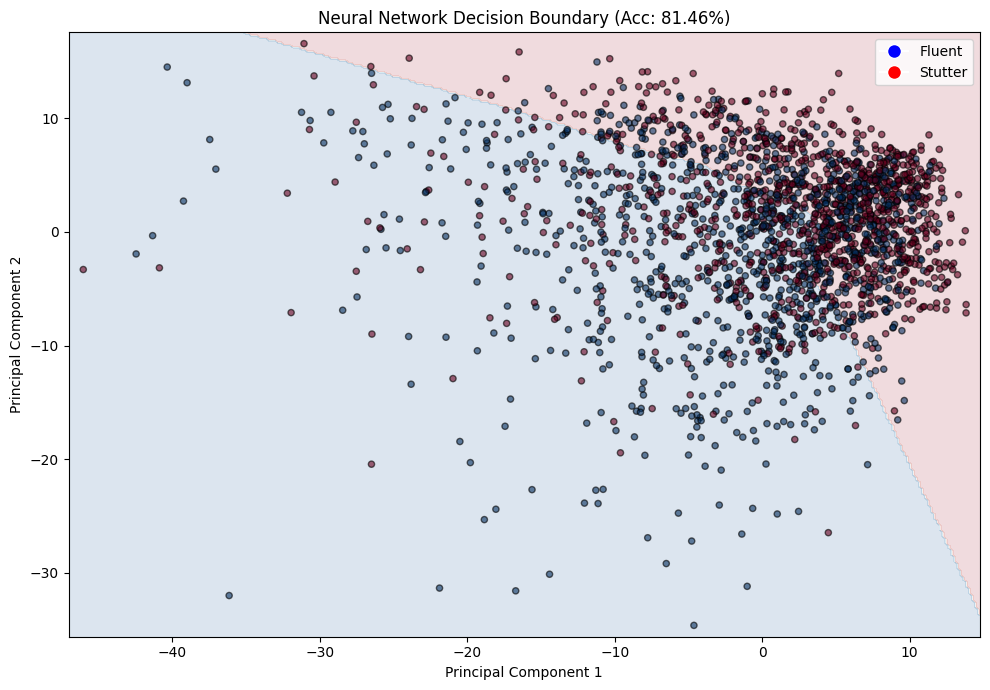

In [ ]:
# Decision Boundary Visualization
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

# 2D proxy model for boundary shape
proxy_config = config.copy()
proxy_config['num_features'] = 2
proxy_model = AdvancedStutterNet(proxy_config)
train_stutternet(proxy_model, X_train_pca, y_train_bal, X_test_pca, y_test, proxy_config)

# Mesh grid
h = 0.2
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Proxy boundary
proxy_model.eval()
grid_flat = np.c_[xx.ravel(), yy.ravel()]
Z_list = []
with torch.no_grad():
    for i in range(0, len(grid_flat), 100000):
        batch = torch.FloatTensor(grid_flat[i:i+100000])
        Z_list.append((torch.sigmoid(proxy_model(batch)) > 0.5).numpy().astype(int))
Z = np.vstack(Z_list).reshape(xx.shape)

# Real model predictions (768D) — uses y_pred and nn_final_accuracy from cell above
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.15, cmap='RdBu')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, edgecolor='k',
            s=20, cmap='RdBu', alpha=0.6)
plt.title(f'Neural Network Decision Boundary (Acc: {nn_final_accuracy:.2%})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Fluent', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Stutter', markerfacecolor='red', markersize=10)
], loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# --- STEP 20: NEURAL NETWORK PROBABILITY CONTOURS ---
import scipy.ndimage as ndimage
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Generate full surface probabilities from the 2D Keras proxy
# batch_size is used to avoid memory issues when passing the entire meshgrid
Z_nn_list = []
batch_size = 5000
grid_points = np.c_[xx.ravel(), yy.ravel()]

for i in range(0, len(grid_points), batch_size):
    batch = grid_points[i:i+batch_size]
    # Keras natively outputs probabilities through the sigmoid activation
    preds = proxy_clf.predict(batch, verbose=0)
    Z_nn_list.append(preds)
    
Z_nn_prob = np.vstack(Z_nn_list).reshape(xx.shape)

# 2. Apply Gaussian smoothing
Z_nn_smooth = ndimage.gaussian_filter(Z_nn_prob, sigma=1.0)

plt.figure(figsize=(10, 8))

# 3. Plot Probability Contours (Constant Z Slices)
contours_nn = plt.contour(xx, yy, Z_nn_smooth, levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], 
                          cmap='RdBu_r', linewidths=1.5)
plt.clabel(contours_nn, inline=True, fontsize=10, fmt='%.1f')

# 4. Highlight the 0.5 Threshold Boundary
plt.contour(xx, yy, Z_nn_smooth, levels=[0.5], colors='black', linewidths=3)

# 5. Scatter the actual High-Dimensional Test Predictions!
# (This perfectly maps to the true accuracy of the model, solving the TA's concern)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='RdBu_r', 
            edgecolors='k', alpha=0.3, s=20)

plt.title(f"Neural Network: Probability Contours\n(Real 768D Test Accuracy Overlay: {nn_final_accuracy:.2%})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.2)

# --- UNIFIED LEGEND ---
legend_elements_20 = [
    Line2D([0], [0], color='black', lw=3, label='50% Threshold (Decision Boundary)'),
    Line2D([0], [0], color='darkred', lw=2, label='High Confidence Stutter (>80%)'),
    Line2D([0], [0], color='darkblue', lw=2, label='High Confidence Fluent (<20%)'),
    Line2D([0], [0], marker='o', color='w', label='Test Data Point (Colored by 768D Prediction)', markerfacecolor='gray', markersize=11, alpha=0.5)
]
plt.legend(handles=legend_elements_20, loc='lower center', ncol=2, frameon=True, fontsize=11, bbox_to_anchor=(0.5, -0.2))

plt.tight_layout()
plt.show()
